# Climatological Hail Centroid Analysis
This notebook reproduces the hail-only centroid drift and population exposure workflow using SPC hail reports, Census tract population, and a Theil-Sen robust linear trend fit.

In [2]:
import json
import re
from datetime import datetime
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen, urlretrieve
from zipfile import ZipFile

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
from matplotlib.lines import Line2D
from sklearn.linear_model import TheilSenRegressor

SPC_INDEX_URL = "https://www.spc.noaa.gov/gis/svrgis/"
SPC_BASE_URL = "https://www.spc.noaa.gov/gis/svrgis/"
STATE_BOUNDARIES_URL = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_20m.zip"
ACS5_YEAR = 2024
ACS5_TOTAL_POP_VARIABLE = "B01003_001E"
ACS5_TRACTS_URL = f"https://www2.census.gov/geo/tiger/GENZ{ACS5_YEAR}/shp/cb_{ACS5_YEAR}_us_tract_500k.zip"
ACS5_API_BASE_URL = f"https://api.census.gov/data/{ACS5_YEAR}/acs/acs5"
WORKSPACE_ROOT = Path.cwd()
CACHE_DIR = WORKSPACE_ROOT / ".cache" / "spc_svrgis"
REFERENCE_DIR = WORKSPACE_ROOT / ".cache" / "reference_layers"
EQUAL_AREA_CRS = "EPSG:5070"
PLOT_CRS = "EPSG:3857"
CURRENT_YEAR = datetime.now().year
CONUS_EXCLUDED_STATEFP = {"02", "15", "60", "66", "69", "72", "78"}
HAIL_ARCHIVE_PATTERN = r"(?:\./)?zipped/(?P<archive>\d{4}-\d{4}-hail-initpoint\.zip)"
HAIL_FORECAST_YEARS = 50
EXPOSURE_RADIUS_50_MILES = 50
EXPOSURE_RADIUS_50_METERS = EXPOSURE_RADIUS_50_MILES * 1609.344
EXPOSURE_RADIUS_100_MILES = 100
EXPOSURE_RADIUS_100_METERS = EXPOSURE_RADIUS_100_MILES * 1609.344
EXPOSURE_RADIUS_200_MILES = 200
EXPOSURE_RADIUS_200_METERS = EXPOSURE_RADIUS_200_MILES * 1609.344
ROBUST_TREND_LABEL = "Theil-Sen robust linear trend"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
REFERENCE_DIR.mkdir(parents=True, exist_ok=True)


class DataLoadError(RuntimeError):
    pass


def build_year_windows(years, nominal_interval):
    if not years:
        raise ValueError("At least one analysis year is required.")

    if nominal_interval == 1:
        return [
            {
                "start_year": year,
                "end_year": year,
                "interval_length": nominal_interval,
                "year_count": 1,
            }
            for year in years
        ]

    remainder = len(years) % nominal_interval
    first_window_size = nominal_interval + remainder if remainder else nominal_interval
    windows = []
    index = 0

    while index < len(years):
        window_size = first_window_size if index == 0 else nominal_interval
        window_years = years[index:index + window_size]
        windows.append(
            {
                "start_year": window_years[0],
                "end_year": window_years[-1],
                "interval_length": nominal_interval,
                "year_count": len(window_years),
            }
        )
        index += window_size
        first_window_size = nominal_interval

    return windows


def ensure_reference_states():
    states_zip_path = REFERENCE_DIR / "cb_2024_us_state_20m.zip"
    states_extract_dir = REFERENCE_DIR / "cb_2024_us_state_20m"
    states_shapefile_path = states_extract_dir / "cb_2024_us_state_20m.shp"

    if not states_zip_path.exists():
        print(f"Downloading Census reference states layer: {STATE_BOUNDARIES_URL}")
        urlretrieve(STATE_BOUNDARIES_URL, states_zip_path)

    if not states_shapefile_path.exists():
        print(f"Extracting reference states layer to: {states_extract_dir}")
        with ZipFile(states_zip_path) as archive:
            archive.extractall(states_extract_dir)

    if not states_shapefile_path.exists():
        raise DataLoadError(
            f"Expected reference layer shapefile was not found after extraction: {states_shapefile_path}"
        )

    states_gdf = gpd.read_file(states_shapefile_path)
    if states_gdf.empty or states_gdf.crs is None:
        raise DataLoadError("The Census reference states layer could not be loaded with a valid CRS.")

    states_gdf = states_gdf.loc[~states_gdf["STATEFP"].isin(CONUS_EXCLUDED_STATEFP)].copy()
    if states_gdf.empty:
        raise DataLoadError("The filtered CONUS reference states layer is empty.")

    return states_gdf.to_crs(PLOT_CRS)


def fit_centroid_robust_trend(plot_gdf):
    sequence = np.arange(len(plot_gdf), dtype=float).reshape(-1, 1)
    x_values = plot_gdf.geometry.x.to_numpy(dtype=float)
    y_values = plot_gdf.geometry.y.to_numpy(dtype=float)
    total_ss = np.sum((x_values - x_values.mean()) ** 2 + (y_values - y_values.mean()) ** 2)

    x_model = TheilSenRegressor(random_state=42)
    y_model = TheilSenRegressor(random_state=42)
    x_model.fit(sequence, x_values)
    y_model.fit(sequence, y_values)

    x_fit = x_model.predict(sequence)
    y_fit = y_model.predict(sequence)
    residual_ss = float(np.sum((x_values - x_fit) ** 2 + (y_values - y_fit) ** 2))
    r_squared = 1.0 - (residual_ss / total_ss) if total_ss > 0 else 1.0

    return {
        "label": ROBUST_TREND_LABEL,
        "x_model": x_model,
        "y_model": y_model,
        "x_fit": x_fit,
        "y_fit": y_fit,
        "r_squared": float(r_squared),
        "x_slope": float(x_model.coef_[0]),
        "y_slope": float(y_model.coef_[0]),
    }


def build_extrapolated_centroids(plot_gdf, best_fit, years_forward=HAIL_FORECAST_YEARS):
    interval_length = int(plot_gdf["interval_length"].iloc[0])
    if years_forward % interval_length != 0:
        raise DataLoadError(
            f"Forecast horizon {years_forward} is not divisible by interval length {interval_length}."
        )

    forecast_count = years_forward // interval_length
    forecast_sequence = np.arange(len(plot_gdf), len(plot_gdf) + forecast_count, dtype=float).reshape(-1, 1)
    forecast_x = best_fit["x_model"].predict(forecast_sequence)
    forecast_y = best_fit["y_model"].predict(forecast_sequence)
    last_end_year = int(plot_gdf["end_year"].max())
    forecast_records = []

    for step_index, (x_coord, y_coord) in enumerate(zip(forecast_x, forecast_y), start=1):
        forecast_start_year = last_end_year + ((step_index - 1) * interval_length) + 1
        forecast_end_year = forecast_start_year + interval_length - 1
        forecast_records.append(
            {
                "sequence_index": len(plot_gdf) + step_index - 1,
                "start_year": forecast_start_year,
                "end_year": forecast_end_year,
                "interval_length": interval_length,
                "year_count": interval_length,
                "is_extrapolated": True,
                "geometry": shapely.Point(float(x_coord), float(y_coord)),
            }
        )

    forecast_gdf = gpd.GeoDataFrame(forecast_records, geometry="geometry", crs=PLOT_CRS)

    return {
        "forecast_gdf": forecast_gdf,
        "full_x_fit": np.concatenate([best_fit["x_fit"], forecast_x]),
        "full_y_fit": np.concatenate([best_fit["y_fit"], forecast_y]),
    }


def fetch_census_json(base_url, params):
    url = f"{base_url}?{urlencode(params)}"
    with urlopen(url) as response:
        return json.loads(response.read().decode("utf-8"))


def rows_to_population_records(rows):
    if not rows or len(rows) == 1:
        return []

    records = []
    for population, state_fips, county_fips, tract_fips in rows[1:]:
        records.append(
            {
                "GEOID": f"{state_fips}{county_fips}{tract_fips}",
                "population": pd.to_numeric(population, errors="coerce"),
            }
        )
    return records


def ensure_census_tract_population_surface():
    tract_zip_path = REFERENCE_DIR / f"cb_{ACS5_YEAR}_us_tract_500k.zip"
    tract_extract_dir = REFERENCE_DIR / f"cb_{ACS5_YEAR}_us_tract_500k"
    tract_shapefile_path = tract_extract_dir / f"cb_{ACS5_YEAR}_us_tract_500k.shp"
    population_cache_path = REFERENCE_DIR / f"acs5_{ACS5_YEAR}_tract_population.csv"

    if not tract_zip_path.exists():
        print(f"Downloading Census tract geometry layer: {ACS5_TRACTS_URL}")
        urlretrieve(ACS5_TRACTS_URL, tract_zip_path)

    if not tract_shapefile_path.exists():
        print(f"Extracting Census tract geometry layer to: {tract_extract_dir}")
        with ZipFile(tract_zip_path) as archive:
            archive.extractall(tract_extract_dir)

    if not tract_shapefile_path.exists():
        raise DataLoadError(f"Expected Census tract shapefile was not found: {tract_shapefile_path}")

    tract_gdf = gpd.read_file(tract_shapefile_path)
    tract_gdf = tract_gdf.loc[
        ~tract_gdf["STATEFP"].isin(CONUS_EXCLUDED_STATEFP),
        ["GEOID", "STATEFP", "COUNTYFP", "geometry"],
    ].copy()

    if tract_gdf.empty or tract_gdf.crs is None:
        raise DataLoadError("The Census tract geometry layer could not be loaded with a valid CRS.")

    if population_cache_path.exists():
        tract_population_df = pd.read_csv(population_cache_path, dtype={"GEOID": str})
    else:
        print(f"Downloading ACS {ACS5_YEAR} 5-year tract population totals.")
        population_records = []
        state_fips_values = tract_gdf["STATEFP"].drop_duplicates().sort_values().tolist()
        supports_state_county_wildcard = True

        try:
            fetch_census_json(
                ACS5_API_BASE_URL,
                [
                    ("get", ACS5_TOTAL_POP_VARIABLE),
                    ("for", "tract:*"),
                    ("in", f"state:{state_fips_values[0]}"),
                    ("in", "county:*"),
                ],
            )
        except Exception:
            supports_state_county_wildcard = False

        for state_fips in state_fips_values:
            if supports_state_county_wildcard:
                rows = fetch_census_json(
                    ACS5_API_BASE_URL,
                    [
                        ("get", ACS5_TOTAL_POP_VARIABLE),
                        ("for", "tract:*"),
                        ("in", f"state:{state_fips}"),
                        ("in", "county:*"),
                    ],
                )
                population_records.extend(rows_to_population_records(rows))
                continue

            county_fips_values = (
                tract_gdf.loc[tract_gdf["STATEFP"] == state_fips, "COUNTYFP"]
                .drop_duplicates()
                .sort_values()
                .tolist()
            )
            for county_fips in county_fips_values:
                rows = fetch_census_json(
                    ACS5_API_BASE_URL,
                    [
                        ("get", ACS5_TOTAL_POP_VARIABLE),
                        ("for", "tract:*"),
                        ("in", f"state:{state_fips}"),
                        ("in", f"county:{county_fips}"),
                    ],
                )
                population_records.extend(rows_to_population_records(rows))

        tract_population_df = pd.DataFrame(population_records).drop_duplicates(subset=["GEOID"])
        tract_population_df.to_csv(population_cache_path, index=False)

    tract_population_surface = tract_gdf.merge(tract_population_df, on="GEOID", how="left")
    missing_population_count = int(tract_population_surface["population"].isna().sum())
    if missing_population_count:
        print(
            f"Warning: {missing_population_count:,} tracts are missing ACS population totals; treating them as zero population."
        )

    tract_population_surface["population"] = (
        pd.to_numeric(tract_population_surface["population"], errors="coerce").fillna(0).astype(float)
    )
    tract_population_surface = tract_population_surface.to_crs(EQUAL_AREA_CRS)
    tract_population_surface["tract_area_sq_m"] = tract_population_surface.geometry.area
    tract_population_surface = tract_population_surface.loc[tract_population_surface["tract_area_sq_m"] > 0].copy()

    if tract_population_surface.empty:
        raise DataLoadError("The Census tract population surface is empty after preparation.")

    return tract_population_surface


def summarize_population_within_radius(point_gdf, tract_population_surface, radius_m):
    points = point_gdf.sort_values(["start_year", "end_year"]).reset_index(drop=True).copy()
    if points.crs is None:
        raise DataLoadError("The centroid point layer is missing a CRS.")
    if points.crs.to_string() != EQUAL_AREA_CRS:
        points = points.to_crs(EQUAL_AREA_CRS)

    points["buffer_index"] = points.index
    points["point_type"] = np.where(points["is_extrapolated"], "Forecast", "Observed")
    points["period"] = points["start_year"].astype(str) + "-" + points["end_year"].astype(str)

    buffer_gdf = gpd.GeoDataFrame(
        points[["buffer_index", "point_type", "period", "start_year", "end_year", "geometry"]].copy(),
        geometry=points.geometry.buffer(radius_m),
        crs=EQUAL_AREA_CRS,
    )
    tract_index = tract_population_surface[["GEOID", "population", "tract_area_sq_m", "geometry"]].copy()
    tract_index["tract_index"] = tract_index.index

    candidate_pairs = gpd.sjoin(buffer_gdf, tract_index, how="left", predicate="intersects").dropna(subset=["tract_index"]).copy()

    if candidate_pairs.empty:
        raise DataLoadError("No Census tracts intersect the centroid exposure buffers.")

    candidate_pairs = candidate_pairs.rename(columns={"geometry": "buffer_geometry"})
    candidate_pairs = candidate_pairs.merge(
        tract_index[["tract_index", "geometry"]].rename(columns={"geometry": "tract_geometry"}),
        on="tract_index",
        how="left",
    )

    intersection_geometries = shapely.intersection(candidate_pairs["buffer_geometry"].array, candidate_pairs["tract_geometry"].array)
    candidate_pairs["intersection_area_sq_m"] = shapely.area(intersection_geometries)
    candidate_pairs = candidate_pairs.loc[candidate_pairs["intersection_area_sq_m"] > 0].copy()
    candidate_pairs["population_contribution"] = candidate_pairs["population"] * (
        candidate_pairs["intersection_area_sq_m"] / candidate_pairs["tract_area_sq_m"]
    )

    exposure_by_point = candidate_pairs.groupby("buffer_index")["population_contribution"].sum()
    points["population_within_miles"] = points["buffer_index"].map(exposure_by_point).fillna(0).round().astype(int)

    return points[["point_type", "period", "start_year", "end_year", "population_within_miles"]]

Using cached SPC hail reports archive: c:\Users\max.keller\OneDrive - Baron Services\Desktop\gis-polygon-merge\.cache\spc_svrgis\1955-2024-hail-initpoint.zip
Added 9,367 hail reports from annual SPC CSV for 2025.
Added 1,835 hail reports from daily SPC raw reports for 2026 through 2026-04-16.
Loaded 416,112 hail reports spanning 1955-2026. Included 2026 year-to-date reports through 2026-04-16: 1,835.


C:\Users\max.keller\AppData\Local\Temp\ipykernel_38920\1320632098.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid_geometry = window_points.geometry.unary_union.centroid
C:\Users\max.keller\AppData\Local\Temp\ipykernel_38920\1320632098.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid_geometry = window_points.geometry.unary_union.centroid
C:\Users\max.keller\AppData\Local\Temp\ipykernel_38920\1320632098.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid_geometry = window_points.geometry.unary_union.centroid
C:\Users\max.keller\AppData\Local\Temp\ipykernel_38920\1320632098.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid_geometry = window_points.geometry.unary_union.centroid
C:\Users\max.keller\AppData\Local\Temp\i

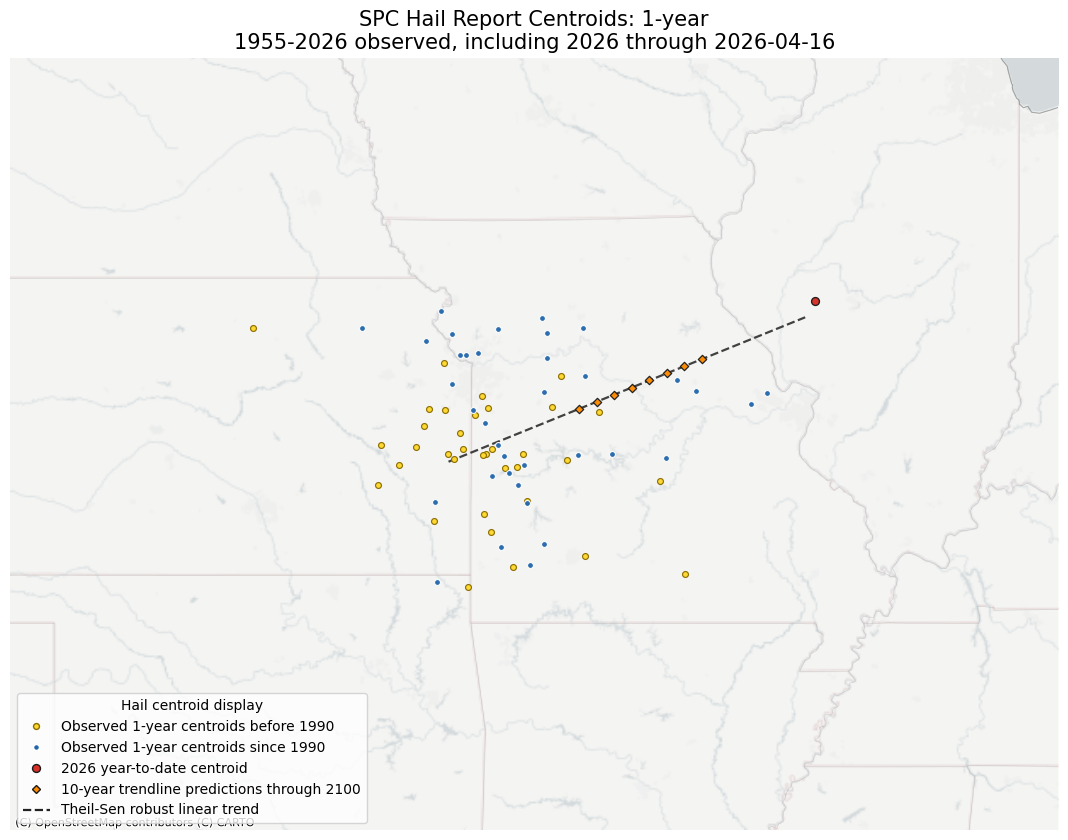


Hail centroid feature counts:


,interval,centroid_count,forecast_count
0,1-year,72,50
1,5-year,14,10
2,10-year,7,5



Hail best-fit summary:


,interval,best_fit,r_squared,x_slope_m_per_step,y_slope_m_per_step,forecast_count,forecast_end_year
0,1-year,Theil-Sen robust linear trend,0.125,2513.1,1017.7,50,2076
1,5-year,Theil-Sen robust linear trend,0.136,12042.1,4703.9,10,2076
2,10-year,Theil-Sen robust linear trend,-0.124,16177.4,5395.4,5,2076


In [9]:
def aggregate_hail_window_centroids(point_gdf, years, nominal_interval):
    records = []
    for window in build_year_windows(years, nominal_interval):
        window_points = point_gdf.loc[point_gdf["report_year"].between(window["start_year"], window["end_year"])].copy()

        if window_points.empty:
            raise DataLoadError(
                "No hail report points were found for window "
                f"{window['start_year']}-{window['end_year']}."
            )

        centroid_geometry = window_points.geometry.unary_union.centroid
        if centroid_geometry is None or centroid_geometry.is_empty or not centroid_geometry.is_valid:
            raise DataLoadError(
                "Centroid generation failed for hail window "
                f"{window['start_year']}-{window['end_year']}."
            )

        records.append({**window, "point_count": int(len(window_points)), "geometry": centroid_geometry})

    centroid_gdf = gpd.GeoDataFrame(records, geometry="geometry", crs=EQUAL_AREA_CRS)
    if centroid_gdf.empty:
        raise DataLoadError(f"No hail centroids were generated for the {nominal_interval}-year interval.")
    return centroid_gdf.sort_values(["start_year", "end_year"]).reset_index(drop=True)


def empty_hail_point_gdf():
    return gpd.GeoDataFrame(
        {"report_year": pd.Series(dtype="int64")},
        geometry=gpd.GeoSeries([], crs="EPSG:4326"),
        crs="EPSG:4326",
    )


def load_spc_annual_hail_csv(year):
    annual_url = f"https://www.spc.noaa.gov/wcm/data/{year}_hail.csv"
    try:
        annual_df = pd.read_csv(annual_url, low_memory=False)
    except Exception:
        return empty_hail_point_gdf()

    if annual_df.empty:
        return empty_hail_point_gdf()

    annual_df.columns = [str(column).strip() for column in annual_df.columns]
    if "yr" in annual_df.columns:
        annual_df["report_year"] = pd.to_numeric(annual_df["yr"], errors="coerce")
    elif "date" in annual_df.columns:
        annual_df["report_year"] = pd.to_datetime(annual_df["date"], errors="coerce").dt.year
    else:
        annual_df["report_year"] = year

    if "slat" not in annual_df.columns or "slon" not in annual_df.columns:
        return empty_hail_point_gdf()

    annual_df["slat"] = pd.to_numeric(annual_df["slat"], errors="coerce")
    annual_df["slon"] = pd.to_numeric(annual_df["slon"], errors="coerce")
    annual_df = annual_df.loc[
        annual_df["report_year"].notna() & annual_df["slat"].notna() & annual_df["slon"].notna()
    ].copy()

    if annual_df.empty:
        return empty_hail_point_gdf()

    annual_df["report_year"] = annual_df["report_year"].astype(int)
    annual_df["geometry"] = gpd.points_from_xy(annual_df["slon"], annual_df["slat"], crs="EPSG:4326")
    return gpd.GeoDataFrame(annual_df, geometry="geometry", crs="EPSG:4326")


def load_spc_daily_hail_reports(year, end_date=None):
    if end_date is None:
        end_date = pd.Timestamp(datetime.now().date())

    daily_frames = []
    for report_date in pd.date_range(f"{year}-01-01", end_date, freq="D"):
        daily_url = f"https://www.spc.noaa.gov/climo/reports/{report_date:%y%m%d}_rpts_raw_hail.csv"
        try:
            daily_df = pd.read_csv(daily_url, skiprows=1)
        except Exception:
            continue

        if daily_df.empty:
            continue

        daily_df.columns = [str(column).strip() for column in daily_df.columns]
        lat_column = next((column for column in daily_df.columns if column.upper() == "LAT"), None)
        lon_column = next((column for column in daily_df.columns if column.upper() == "LON"), None)
        if lat_column is None or lon_column is None:
            continue

        daily_df["latitude"] = pd.to_numeric(daily_df[lat_column], errors="coerce")
        daily_df["longitude"] = pd.to_numeric(daily_df[lon_column], errors="coerce")
        daily_df["report_year"] = int(report_date.year)
        daily_df["report_date"] = report_date.strftime("%Y-%m-%d")
        daily_df = daily_df.loc[daily_df["latitude"].notna() & daily_df["longitude"].notna()].copy()

        if daily_df.empty:
            continue

        daily_frames.append(daily_df)

    if not daily_frames:
        return empty_hail_point_gdf()

    current_df = pd.concat(daily_frames, ignore_index=True)
    current_df["geometry"] = gpd.points_from_xy(current_df["longitude"], current_df["latitude"], crs="EPSG:4326")
    return gpd.GeoDataFrame(current_df, geometry="geometry", crs="EPSG:4326")


def build_decadal_trendline_points(plot_gdf, best_fit, final_year=2100, step=10):
    observed_end_year = int(plot_gdf["end_year"].max())
    analysis_start_year = int(plot_gdf["start_year"].min())
    first_projection_year = ((observed_end_year // step) + 1) * step
    target_years = list(range(first_projection_year, final_year + 1, step))

    if not target_years:
        return gpd.GeoDataFrame(
            {"prediction_year": pd.Series(dtype="int64")},
            geometry=gpd.GeoSeries([], crs=PLOT_CRS),
            crs=PLOT_CRS,
        )

    target_sequence = np.array([year - analysis_start_year for year in target_years], dtype=float).reshape(-1, 1)
    predicted_x = best_fit["x_model"].predict(target_sequence)
    predicted_y = best_fit["y_model"].predict(target_sequence)

    prediction_records = [
        {
            "prediction_year": int(year),
            "geometry": shapely.Point(float(x_coord), float(y_coord)),
        }
        for year, x_coord, y_coord in zip(target_years, predicted_x, predicted_y)
    ]
    return gpd.GeoDataFrame(prediction_records, geometry="geometry", crs=PLOT_CRS)


with urlopen(SPC_INDEX_URL) as response:
    hail_index_html = response.read().decode("utf-8", errors="replace")

hail_archive_match = re.search(HAIL_ARCHIVE_PATTERN, hail_index_html)
if hail_archive_match is None:
    raise DataLoadError("Could not resolve the SPC hail init-point archive from the SVRGIS page.")

hail_archive_name = hail_archive_match.group("archive")
hail_archive_url = f"{SPC_BASE_URL}zipped/{hail_archive_name}"
hail_archive_stem = Path(hail_archive_name).stem
hail_archive_path = CACHE_DIR / hail_archive_name
hail_extract_dir = CACHE_DIR / hail_archive_stem
hail_shapefile_path = hail_extract_dir / hail_archive_stem / f"{hail_archive_stem}.shp"

if not hail_archive_path.exists():
    print(f"Downloading SPC hail reports archive: {hail_archive_url}")
    urlretrieve(hail_archive_url, hail_archive_path)
else:
    print(f"Using cached SPC hail reports archive: {hail_archive_path}")

if not hail_shapefile_path.exists():
    print(f"Extracting hail archive to: {hail_extract_dir}")
    with ZipFile(hail_archive_path) as archive:
        archive.extractall(hail_extract_dir)

if not hail_shapefile_path.exists():
    raise DataLoadError(f"Expected hail shapefile was not found after extraction: {hail_shapefile_path}")

hail_reports_gdf = gpd.read_file(hail_shapefile_path)
if hail_reports_gdf.empty:
    raise DataLoadError("The SPC hail reports dataset loaded successfully but contains no records.")
if hail_reports_gdf.crs is None:
    raise DataLoadError("The SPC hail reports dataset is missing a CRS.")

if "yr" in hail_reports_gdf.columns:
    hail_reports_gdf["report_year"] = pd.to_numeric(hail_reports_gdf["yr"], errors="coerce")
elif "date" in hail_reports_gdf.columns:
    hail_reports_gdf["report_year"] = pd.to_datetime(hail_reports_gdf["date"], errors="coerce").dt.year
else:
    raise DataLoadError("The SPC hail reports dataset does not contain a usable year field.")

hail_reports_gdf = hail_reports_gdf.loc[hail_reports_gdf["report_year"].notna()].copy()
hail_reports_gdf["report_year"] = hail_reports_gdf["report_year"].astype(int)
hail_reports_gdf = hail_reports_gdf.loc[hail_reports_gdf["report_year"] <= CURRENT_YEAR].copy()

if hail_reports_gdf.crs.to_string() != "EPSG:4326":
    hail_reports_gdf = hail_reports_gdf.to_crs("EPSG:4326")

hail_reports_gdf = hail_reports_gdf.loc[
    hail_reports_gdf.geometry.notna()
    & hail_reports_gdf.geometry.geom_type.isin(["Point", "MultiPoint"])
].copy()
hail_reports_gdf["geometry"] = hail_reports_gdf.geometry.map(
    lambda geom: shapely.make_valid(geom) if geom is not None and not geom.is_valid else geom
)
hail_reports_gdf = hail_reports_gdf.loc[hail_reports_gdf.geometry.is_valid].copy()

archive_year_match = re.search(r"(?P<start>\d{4})-(?P<end>\d{4})-hail-initpoint\.zip", hail_archive_name)
archive_end_year = int(archive_year_match.group("end")) if archive_year_match else int(hail_reports_gdf["report_year"].max())
supplemental_gdfs = []

for year in range(archive_end_year + 1, CURRENT_YEAR):
    annual_gdf = load_spc_annual_hail_csv(year)
    if not annual_gdf.empty:
        supplemental_gdfs.append(annual_gdf)
        print(f"Added {len(annual_gdf):,} hail reports from annual SPC CSV for {year}.")

current_year_gdf = load_spc_annual_hail_csv(CURRENT_YEAR)
if current_year_gdf.empty:
    current_year_gdf = load_spc_daily_hail_reports(CURRENT_YEAR)
    if not current_year_gdf.empty:
        print(
            f"Added {len(current_year_gdf):,} hail reports from daily SPC raw reports "
            f"for {CURRENT_YEAR} through {datetime.now():%Y-%m-%d}."
        )
else:
    print(f"Added {len(current_year_gdf):,} hail reports from annual SPC CSV for {CURRENT_YEAR}.")

if not current_year_gdf.empty:
    supplemental_gdfs.append(current_year_gdf)

if supplemental_gdfs:
    hail_reports_gdf = gpd.GeoDataFrame(
        pd.concat([hail_reports_gdf] + supplemental_gdfs, ignore_index=True),
        geometry="geometry",
        crs="EPSG:4326",
    )

if hail_reports_gdf.empty:
    raise DataLoadError("No valid hail report point geometries remain after validation.")

hail_points_gdf = hail_reports_gdf.to_crs(EQUAL_AREA_CRS)
hail_analysis_start_year = int(hail_points_gdf["report_year"].min())
hail_analysis_end_year = int(hail_points_gdf["report_year"].max())
hail_analysis_years = list(range(hail_analysis_start_year, hail_analysis_end_year + 1))
current_year_report_count = int((hail_reports_gdf["report_year"] == CURRENT_YEAR).sum())

print(
    f"Loaded {len(hail_reports_gdf):,} hail reports spanning {hail_analysis_start_year}-{hail_analysis_end_year}. "
    f"Included {CURRENT_YEAR} year-to-date reports through {datetime.now():%Y-%m-%d}: {current_year_report_count:,}."
)

hail_centroids_1yr_gdf = aggregate_hail_window_centroids(hail_points_gdf, hail_analysis_years, 1)
hail_centroids_5yr_gdf = aggregate_hail_window_centroids(hail_points_gdf, hail_analysis_years, 5)
hail_centroids_10yr_gdf = aggregate_hail_window_centroids(hail_points_gdf, hail_analysis_years, 10)
hail_reference_states_plot = ensure_reference_states()
hail_reference_outline_plot = hail_reference_states_plot.dissolve()

hail_centroid_sets = {
    "1-year": {
        "gdf": hail_centroids_1yr_gdf.to_crs(PLOT_CRS),
        "color": "#2166ac",
        "forecast_color": "#f18f01",
        "marker": "o",
        "markersize": 18,
        "linewidth": 0.9,
        "zorder": 4,
    },
    "5-year": {
        "gdf": hail_centroids_5yr_gdf.to_crs(PLOT_CRS),
        "color": "#1a9850",
        "forecast_color": "#9c27b0",
        "marker": "s",
        "markersize": 38,
        "linewidth": 1.35,
        "zorder": 5,
    },
    "10-year": {
        "gdf": hail_centroids_10yr_gdf.to_crs(PLOT_CRS),
        "color": "#d73027",
        "forecast_color": "#2ec4b6",
        "marker": "^",
        "markersize": 64,
        "linewidth": 1.7,
        "zorder": 6,
    },
}

hail_fit_summaries = []
for label, config in hail_centroid_sets.items():
    plot_gdf = config["gdf"].sort_values(["start_year", "end_year"]).reset_index(drop=True)
    best_fit = fit_centroid_robust_trend(plot_gdf)
    extrapolation = build_extrapolated_centroids(plot_gdf, best_fit, years_forward=HAIL_FORECAST_YEARS)
    decadal_prediction_gdf = build_decadal_trendline_points(plot_gdf, best_fit, final_year=2100, step=10)

    config["gdf"] = plot_gdf
    config["best_fit"] = best_fit
    config["forecast_gdf"] = extrapolation["forecast_gdf"]
    config["full_x_fit"] = extrapolation["full_x_fit"]
    config["full_y_fit"] = extrapolation["full_y_fit"]
    config["decadal_prediction_gdf"] = decadal_prediction_gdf

    hail_fit_summaries.append(
        {
            "interval": label,
            "best_fit": best_fit["label"],
            "r_squared": round(best_fit["r_squared"], 3),
            "x_slope_m_per_step": round(best_fit["x_slope"], 1),
            "y_slope_m_per_step": round(best_fit["y_slope"], 1),
            "forecast_count": int(len(config["forecast_gdf"])),
            "forecast_end_year": int(config["forecast_gdf"]["end_year"].max()),
        }
    )

display_label = "1-year"
display_config = hail_centroid_sets[display_label]
plot_gdf = display_config["gdf"]
decadal_prediction_gdf = display_config["decadal_prediction_gdf"]
common_point_size = display_config["markersize"]
current_year_point_size = display_config["markersize"] * 1.8

trend_x = display_config["best_fit"]["x_fit"].astype(float)
trend_y = display_config["best_fit"]["y_fit"].astype(float)
if not decadal_prediction_gdf.empty:
    trend_x = np.concatenate([trend_x, decadal_prediction_gdf.geometry.x.to_numpy(dtype=float)])
    trend_y = np.concatenate([trend_y, decadal_prediction_gdf.geometry.y.to_numpy(dtype=float)])

extension_distance_m = 100 * 1609.344
trend_dx = float(display_config["best_fit"]["x_slope"])
trend_dy = float(display_config["best_fit"]["y_slope"])
trend_norm = float(np.hypot(trend_dx, trend_dy))
if trend_norm == 0:
    trend_dx, trend_dy, trend_norm = 1.0, 1.0, float(np.sqrt(2.0))

trend_x = np.append(trend_x, trend_x[-1] + (trend_dx / trend_norm) * extension_distance_m)
trend_y = np.append(trend_y, trend_y[-1] + (trend_dy / trend_norm) * extension_distance_m)

trend_extension_gdf = gpd.GeoDataFrame(
    {"segment": ["extended_endpoint"]},
    geometry=[shapely.Point(float(trend_x[-1]), float(trend_y[-1]))],
    crs=PLOT_CRS,
)
plot_extent_gdf = gpd.GeoDataFrame(
    pd.concat([plot_gdf, decadal_prediction_gdf, trend_extension_gdf], ignore_index=True),
    geometry="geometry",
    crs=PLOT_CRS,
)

min_x, min_y, max_x, max_y = plot_extent_gdf.total_bounds
x_pad = max((max_x - min_x) * 0.18, 350000)
y_pad = max((max_y - min_y) * 0.18, 350000)

pre_1990_mask = plot_gdf["end_year"] < 1990
post_1990_mask = (plot_gdf["end_year"] >= 1990) & (plot_gdf["end_year"] < CURRENT_YEAR)
current_year_mask = plot_gdf["end_year"] == CURRENT_YEAR

fig, ax = plt.subplots(figsize=(12.5, 8.5))
ax.set_xlim(min_x - x_pad, max_x + x_pad)
ax.set_ylim(min_y - y_pad, max_y + y_pad)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs=PLOT_CRS)

hail_reference_states_plot.plot(ax=ax, facecolor="#d9d9d9", edgecolor="#9a9a9a", linewidth=0.45, alpha=0.18, zorder=1.5)
hail_reference_outline_plot.boundary.plot(ax=ax, color="#666666", linewidth=0.8, alpha=0.5, zorder=1.7)

ax.plot(
    trend_x,
    trend_y,
    color="#222222",
    linewidth=1.6,
    linestyle="--",
    alpha=0.85,
    zorder=3.8,
)

if pre_1990_mask.any():
    pre_1990_points = plot_gdf.loc[pre_1990_mask]
    ax.scatter(
        pre_1990_points.geometry.x,
        pre_1990_points.geometry.y,
        s=common_point_size,
        marker=display_config["marker"],
        c="#ffd92f",
        edgecolors="#8c6d00",
        linewidths=0.85,
        alpha=0.98,
        zorder=5,
    )

if post_1990_mask.any():
    post_1990_points = plot_gdf.loc[post_1990_mask]
    ax.scatter(
        post_1990_points.geometry.x,
        post_1990_points.geometry.y,
        s=common_point_size,
        marker=display_config["marker"],
        c="#2166ac",
        edgecolors="white",
        linewidths=0.8,
        alpha=0.95,
        zorder=5.1,
    )

if current_year_mask.any():
    current_year_points = plot_gdf.loc[current_year_mask]
    ax.scatter(
        current_year_points.geometry.x,
        current_year_points.geometry.y,
        s=current_year_point_size,
        marker=display_config["marker"],
        c="#d73027",
        edgecolors="#1a1a1a",
        linewidths=0.95,
        alpha=0.98,
        zorder=5.3,
    )

if not decadal_prediction_gdf.empty:
    ax.scatter(
        decadal_prediction_gdf.geometry.x,
        decadal_prediction_gdf.geometry.y,
        s=common_point_size,
        marker="D",
        c="#ff8c00",
        edgecolors="#1a1a1a",
        linewidths=0.9,
        alpha=0.96,
        zorder=5.5,
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        color="none",
        marker=display_config["marker"],
        markersize=np.sqrt(common_point_size),
        markerfacecolor="#ffd92f",
        markeredgecolor="#8c6d00",
        label="Observed 1-year centroids before 1990",
    ),
    Line2D(
        [0],
        [0],
        color="none",
        marker=display_config["marker"],
        markersize=np.sqrt(common_point_size),
        markerfacecolor="#2166ac",
        markeredgecolor="white",
        label="Observed 1-year centroids since 1990",
    ),
]

if current_year_mask.any():
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="none",
            marker=display_config["marker"],
            markersize=np.sqrt(current_year_point_size),
            markerfacecolor="#d73027",
            markeredgecolor="#1a1a1a",
            label=f"{CURRENT_YEAR} year-to-date centroid",
        )
    )

if not decadal_prediction_gdf.empty:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="none",
            marker="D",
            markersize=np.sqrt(common_point_size),
            markerfacecolor="#ff8c00",
            markeredgecolor="#1a1a1a",
            label="10-year trendline predictions through 2100",
        )
    )

legend_handles.append(
    Line2D([0], [0], color="#222222", linewidth=1.6, linestyle="--", label=ROBUST_TREND_LABEL)
)

ax.legend(handles=legend_handles, loc="lower left", frameon=True, title="Hail centroid display")
ax.set_title(
    f"SPC Hail Report Centroids: {display_label}\n"
    f"{hail_analysis_start_year}-{hail_analysis_end_year} observed, including {CURRENT_YEAR} through {datetime.now():%Y-%m-%d}",
    fontsize=15,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("\nHail centroid feature counts:")
display(
    pd.DataFrame(
        {
            "interval": ["1-year", "5-year", "10-year"],
            "centroid_count": [len(hail_centroids_1yr_gdf), len(hail_centroids_5yr_gdf), len(hail_centroids_10yr_gdf)],
            "forecast_count": [
                len(hail_centroid_sets["1-year"]["forecast_gdf"]),
                len(hail_centroid_sets["5-year"]["forecast_gdf"]),
                len(hail_centroid_sets["10-year"]["forecast_gdf"]),
            ],
        }
    )
)

print("\nHail best-fit summary:")
display(pd.DataFrame(hail_fit_summaries))

In [10]:
tract_population_surface = ensure_census_tract_population_surface()


def build_interval_population_exposure(observed_gdf, forecast_gdf):
    interval_points = gpd.GeoDataFrame(
        pd.concat([observed_gdf.assign(is_extrapolated=False), forecast_gdf.to_crs(EQUAL_AREA_CRS)], ignore_index=True),
        geometry="geometry",
        crs=EQUAL_AREA_CRS,
    ).sort_values(["start_year", "end_year"]).reset_index(drop=True)

    exposure_50mi_df = summarize_population_within_radius(interval_points, tract_population_surface, radius_m=EXPOSURE_RADIUS_50_METERS).rename(columns={"population_within_miles": "population_within_50mi"})
    exposure_100mi_df = summarize_population_within_radius(interval_points, tract_population_surface, radius_m=EXPOSURE_RADIUS_100_METERS).rename(columns={"population_within_miles": "population_within_100mi"})
    exposure_200mi_df = summarize_population_within_radius(interval_points, tract_population_surface, radius_m=EXPOSURE_RADIUS_200_METERS).rename(columns={"population_within_miles": "population_within_200mi"})

    return exposure_50mi_df.merge(exposure_100mi_df, on=["point_type", "period", "start_year", "end_year"], how="inner").merge(
        exposure_200mi_df,
        on=["point_type", "period", "start_year", "end_year"],
        how="inner",
    )


hail_population_exposure_tables = {}
for interval_label, interval_config in hail_centroid_sets.items():
    interval_exposure_df = build_interval_population_exposure(interval_config["gdf"].to_crs(EQUAL_AREA_CRS), interval_config["forecast_gdf"])
    interval_exposure_df.insert(0, "interval", interval_label)
    hail_population_exposure_tables[interval_label] = interval_exposure_df

hail_population_exposure_df = pd.concat(
    [hail_population_exposure_tables["1-year"], hail_population_exposure_tables["5-year"], hail_population_exposure_tables["10-year"]],
    ignore_index=True,
)

print("\nHail population exposure within 50, 100, and 200 miles for 1-year centroids:")
display(hail_population_exposure_tables["1-year"])

print("\nHail population exposure within 50, 100, and 200 miles for 5-year centroids:")
display(hail_population_exposure_tables["5-year"])

print("\nHail population exposure within 50, 100, and 200 miles for 10-year centroids:")
display(hail_population_exposure_tables["10-year"])

print("\nCombined hail population exposure table:")
display(hail_population_exposure_df)


Hail population exposure within 50, 100, and 200 miles for 1-year centroids:


,interval,point_type,period,start_year,end_year,population_within_50mi,population_within_100mi,population_within_200mi
0,1-year,Observed,1955-1955,1955,1955,924282,3685822,9113179
1,1-year,Observed,1956-1956,1956,1956,2577809,3205945,8953107
2,1-year,Observed,1957-1957,1957,1957,128906,2659563,9368348
3,1-year,Observed,1958-1958,1958,1958,185016,897268,6315587
4,1-year,Observed,1959-1959,1959,1959,170627,3394907,8874187
...,...,...,...,...,...,...,...,...
117,1-year,Forecast,2072-2072,2072,2072,474373,2101825,11196883
118,1-year,Forecast,2073-2073,2073,2073,467194,2140454,11249386
119,1-year,Forecast,2074-2074,2074,2074,464485,2194950,11303709
120,1-year,Forecast,2075-2075,2075,2075,462663,2266778,11345288



Hail population exposure within 50, 100, and 200 miles for 5-year centroids:


,interval,point_type,period,start_year,end_year,population_within_50mi,population_within_100mi,population_within_200mi
0,5-year,Observed,1955-1961,1955,1961,1948358,3230647,9566009
1,5-year,Observed,1962-1966,1962,1966,2369519,3201640,9568374
2,5-year,Observed,1967-1971,1967,1971,219934,3675829,10092458
3,5-year,Observed,1972-1976,1972,1976,307139,3724112,10771951
4,5-year,Observed,1977-1981,1977,1981,2169892,3290915,9446064
5,5-year,Observed,1982-1986,1982,1986,316401,3102104,10676204
6,5-year,Observed,1987-1991,1987,1991,620949,2618151,10071494
7,5-year,Observed,1992-1996,1992,1996,346198,3278098,9368798
8,5-year,Observed,1997-2001,1997,2001,1884138,3447719,10428232
9,5-year,Observed,2002-2006,2002,2006,991892,3368726,10509786



Hail population exposure within 50, 100, and 200 miles for 10-year centroids:


,interval,point_type,period,start_year,end_year,population_within_50mi,population_within_100mi,population_within_200mi
0,10-year,Observed,1955-1966,1955,1966,2341121,3203538,9644695
1,10-year,Observed,1967-1976,1967,1976,277852,3756153,10828176
2,10-year,Observed,1977-1986,1977,1986,305020,3731368,10213830
3,10-year,Observed,1987-1996,1987,1996,298900,3332459,9629740
4,10-year,Observed,1997-2006,1997,2006,1995290,3446591,10945692
5,10-year,Observed,2007-2016,2007,2016,447249,2882831,10497554
6,10-year,Observed,2017-2026,2017,2026,2188006,3456589,10320427
7,10-year,Forecast,2027-2036,2027,2036,545524,2748002,10069185
8,10-year,Forecast,2037-2046,2037,2046,541418,2109429,10216455
9,10-year,Forecast,2047-2056,2047,2056,540807,1827453,10302078



Combined hail population exposure table:


,interval,point_type,period,start_year,end_year,population_within_50mi,population_within_100mi,population_within_200mi
0,1-year,Observed,1955-1955,1955,1955,924282,3685822,9113179
1,1-year,Observed,1956-1956,1956,1956,2577809,3205945,8953107
2,1-year,Observed,1957-1957,1957,1957,128906,2659563,9368348
3,1-year,Observed,1958-1958,1958,1958,185016,897268,6315587
4,1-year,Observed,1959-1959,1959,1959,170627,3394907,8874187
...,...,...,...,...,...,...,...,...
153,10-year,Forecast,2027-2036,2027,2036,545524,2748002,10069185
154,10-year,Forecast,2037-2046,2037,2046,541418,2109429,10216455
155,10-year,Forecast,2047-2056,2047,2056,540807,1827453,10302078
156,10-year,Forecast,2057-2066,2057,2066,530939,1837475,10321971


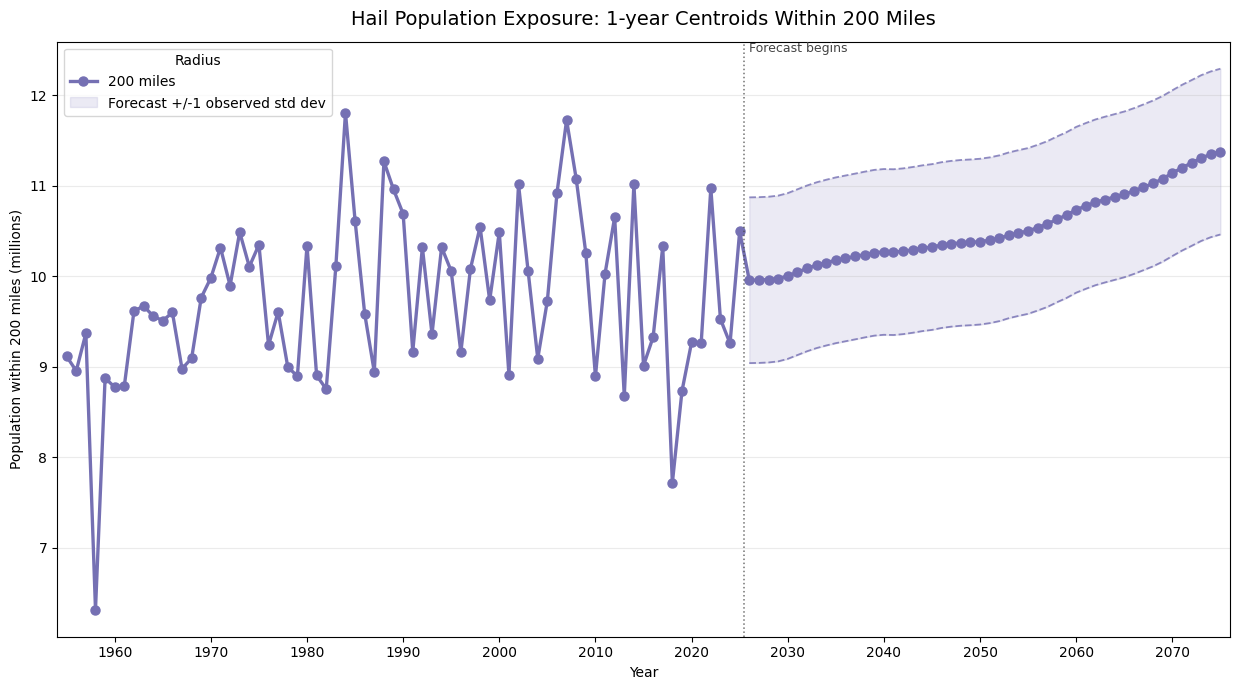

In [14]:
def plot_hail_1yr_population_200mi(exposure_df):
    plot_df = exposure_df.copy().sort_values(["start_year", "end_year"]).reset_index(drop=True)
    plot_df = plot_df.loc[
        ~((plot_df["point_type"] == "Observed") & (plot_df["start_year"] == 2026))
    ].copy()
    plot_df["plot_year"] = np.where(
        plot_df["point_type"] == "Forecast",
        plot_df["start_year"] - 1,
        plot_df["start_year"],
    )
    plot_df["population_millions"] = plot_df["population_within_200mi"] / 1_000_000

    observed_df = plot_df.loc[plot_df["point_type"] == "Observed"].copy()
    forecast_df = plot_df.loc[plot_df["point_type"] == "Forecast"].copy()
    observed_std_millions = observed_df["population_millions"].std(ddof=1)
    if pd.isna(observed_std_millions):
        observed_std_millions = 0.0

    fig, ax = plt.subplots(figsize=(12.5, 7))
    ax.plot(plot_df["plot_year"], plot_df["population_millions"], color="#7570b3", linewidth=2.4, marker="o", markersize=6.5, label="200 miles")

    if not forecast_df.empty and observed_std_millions > 0:
        forecast_upper = forecast_df["population_millions"] + observed_std_millions
        forecast_lower = forecast_df["population_millions"] - observed_std_millions
        ax.fill_between(forecast_df["plot_year"], forecast_lower, forecast_upper, color="#7570b3", alpha=0.14, label="Forecast +/-1 observed std dev")
        ax.plot(forecast_df["plot_year"], forecast_upper, color="#7570b3", linestyle="--", linewidth=1.3, alpha=0.8)
        ax.plot(forecast_df["plot_year"], forecast_lower, color="#7570b3", linestyle="--", linewidth=1.3, alpha=0.8)

    if not observed_df.empty and not forecast_df.empty:
        transition_year = int(forecast_df["plot_year"].min())
        ax.axvline(transition_year - 0.5, color="#444444", linestyle=":", linewidth=1.1, alpha=0.75)
        ax.text(transition_year, ax.get_ylim()[1], "Forecast begins", va="top", ha="left", fontsize=9, color="#444444")

    min_year = int(plot_df["plot_year"].min())
    max_year = int(plot_df["plot_year"].max())
    tick_start = (min_year // 10) * 10
    tick_end = ((max_year + 9) // 10) * 10
    year_ticks = list(range(tick_start, tick_end + 1, 10))

    ax.set_title("Hail Population Exposure: 1-year Centroids Within 200 Miles", fontsize=14, pad=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Population within 200 miles (millions)")
    ax.set_xticks(year_ticks)
    ax.set_xlim(min_year - 1, max_year + 1)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=True, title="Radius")
    plt.tight_layout()
    plt.show()


plot_hail_1yr_population_200mi(hail_population_exposure_tables["1-year"])

In [16]:
from shapely.geometry import LineString
import shutil


def zip_vector_layer(base_path):
    zip_path = base_path.with_suffix(".zip")
    with ZipFile(zip_path, "w") as archive:
        for sidecar_path in base_path.parent.glob(f"{base_path.stem}.*"):
            archive.write(sidecar_path, arcname=sidecar_path.name)
    return zip_path


export_dir = WORKSPACE_ROOT / "data" / "arcgis_webmap_exports"
if export_dir.exists() and export_dir.is_dir():
    shutil.rmtree(export_dir)
export_dir.mkdir(parents=True, exist_ok=True)

observed_1yr_gdf = hail_centroid_sets["1-year"]["gdf"].to_crs("EPSG:4326").copy()
trend_predictions_gdf = hail_centroid_sets["1-year"]["decadal_prediction_gdf"].to_crs("EPSG:4326").copy()

pre_1990_export = observed_1yr_gdf.loc[observed_1yr_gdf["end_year"] < 1990, ["start_year", "end_year", "geometry"]].copy()
pre_1990_export["layer"] = "before_1990"
pre_1990_export = pre_1990_export.rename(columns={"start_year": "start_yr", "end_year": "end_yr"})

since_1990_export = observed_1yr_gdf.loc[
    (observed_1yr_gdf["end_year"] >= 1990) & (observed_1yr_gdf["end_year"] < CURRENT_YEAR),
    ["start_year", "end_year", "geometry"],
].copy()
since_1990_export["layer"] = "since_1990"
since_1990_export = since_1990_export.rename(columns={"start_year": "start_yr", "end_year": "end_yr"})

current_ytd_export = observed_1yr_gdf.loc[
    observed_1yr_gdf["end_year"] == CURRENT_YEAR,
    ["start_year", "end_year", "geometry"],
].copy()
current_ytd_export["layer"] = f"{CURRENT_YEAR}_ytd"
current_ytd_export = current_ytd_export.rename(columns={"start_year": "start_yr", "end_year": "end_yr"})

trend_predictions_export = trend_predictions_gdf[["prediction_year", "geometry"]].copy()
trend_predictions_export["layer"] = "trend_pred"
trend_predictions_export = trend_predictions_export.rename(columns={"prediction_year": "pred_year"})

trendline_points_projected = list(zip(trend_x, trend_y))
trendline_geom = gpd.GeoSeries([LineString(trendline_points_projected)], crs=PLOT_CRS).to_crs("EPSG:4326").iloc[0]
trendline_export = gpd.GeoDataFrame(
    {"name": ["Theil-Sen linear trendline"]},
    geometry=[trendline_geom],
    crs="EPSG:4326",
)

export_layers = {
    "hail_before_1990_points": pre_1990_export,
    "hail_since_1990_points": since_1990_export,
    f"hail_{CURRENT_YEAR}_ytd_point": current_ytd_export,
    "hail_trend_predictions": trend_predictions_export,
    "hail_linear_trendline": trendline_export,
}

for layer_name, layer_gdf in export_layers.items():
    shp_path = export_dir / f"{layer_name}.shp"
    layer_gdf.to_file(shp_path, driver="ESRI Shapefile")
    zip_vector_layer(shp_path)

geopackage_path = export_dir / "hail_webmap_layers.gpkg"
if geopackage_path.exists():
    geopackage_path.unlink()
for layer_name, layer_gdf in export_layers.items():
    layer_gdf.to_file(geopackage_path, layer=layer_name, driver="GPKG")

print("ArcGIS Online export files created:")
for exported_path in sorted(export_dir.iterdir()):
    print(f" - {exported_path.name}")

print("\nRecommended upload choice: the zipped shapefiles for ArcGIS Online compatibility, and the GeoPackage as a master copy.")

ArcGIS Online export files created:
 - hail_2026_ytd_point.cpg
 - hail_2026_ytd_point.dbf
 - hail_2026_ytd_point.prj
 - hail_2026_ytd_point.shp
 - hail_2026_ytd_point.shx
 - hail_2026_ytd_point.zip
 - hail_before_1990_points.cpg
 - hail_before_1990_points.dbf
 - hail_before_1990_points.prj
 - hail_before_1990_points.shp
 - hail_before_1990_points.shx
 - hail_before_1990_points.zip
 - hail_linear_trendline.cpg
 - hail_linear_trendline.dbf
 - hail_linear_trendline.prj
 - hail_linear_trendline.shp
 - hail_linear_trendline.shx
 - hail_linear_trendline.zip
 - hail_since_1990_points.cpg
 - hail_since_1990_points.dbf
 - hail_since_1990_points.prj
 - hail_since_1990_points.shp
 - hail_since_1990_points.shx
 - hail_since_1990_points.zip
 - hail_trend_predictions.cpg
 - hail_trend_predictions.dbf
 - hail_trend_predictions.prj
 - hail_trend_predictions.shp
 - hail_trend_predictions.shx
 - hail_trend_predictions.zip
 - hail_webmap_layers.gpkg

Recommended upload choice: the zipped shapefiles for A

In [17]:
csv_export_dir = WORKSPACE_ROOT / "data" / "arcgis_webmap_exports"
csv_export_dir.mkdir(parents=True, exist_ok=True)

hail_reports_export = hail_reports_gdf.to_crs("EPSG:4326").copy()
hail_reports_export["longitude"] = hail_reports_export.geometry.x.round(6)
hail_reports_export["latitude"] = hail_reports_export.geometry.y.round(6)

before_1990_reports = hail_reports_export.loc[hail_reports_export["report_year"] < 1990].drop(columns="geometry").copy()
since_1990_reports = hail_reports_export.loc[hail_reports_export["report_year"] >= 1990].drop(columns="geometry").copy()

before_1990_csv_path = csv_export_dir / "hail_reports_before_1990.csv"
since_1990_csv_path = csv_export_dir / "hail_reports_1990_and_later.csv"

before_1990_reports.to_csv(before_1990_csv_path, index=False)
since_1990_reports.to_csv(since_1990_csv_path, index=False)

print(f"Created {before_1990_csv_path.name} with {len(before_1990_reports):,} records.")
print(f"Created {since_1990_csv_path.name} with {len(since_1990_reports):,} records.")

Created hail_reports_before_1990.csv with 47,291 records.
Created hail_reports_1990_and_later.csv with 368,821 records.


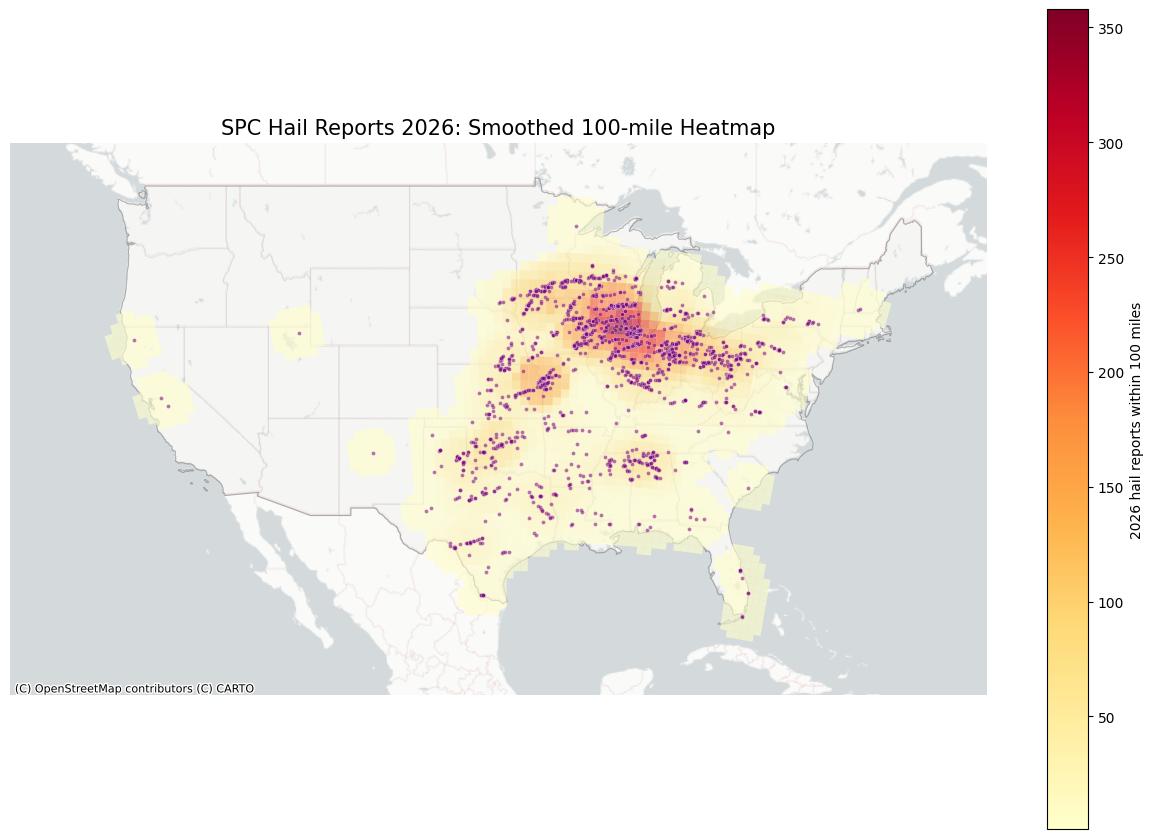

Created hail_2026_reports_points.shp and hail_2026_reports_points.zip
Created hail_2026_smooth_heatmap_100mi.shp and hail_2026_smooth_heatmap_100mi.zip
2026 hail reports plotted: 1,835
Point lon/lat export fields are rounded to 4 decimal places.


In [20]:
from shapely.geometry import box


def zip_sidecars(base_path):
    zip_path = base_path.with_suffix(".zip")
    with ZipFile(zip_path, "w", allowZip64=True) as archive:
        for sidecar_path in base_path.parent.glob(f"{base_path.stem}.*"):
            if sidecar_path.suffix.lower() == ".zip":
                continue
            archive.write(sidecar_path, arcname=sidecar_path.name)
    return zip_path


heatmap_export_dir = WORKSPACE_ROOT / "data" / "arcgis_webmap_exports"
heatmap_export_dir.mkdir(parents=True, exist_ok=True)

hail_2026_points = hail_reports_gdf.loc[hail_reports_gdf["report_year"] == CURRENT_YEAR].copy()
if hail_2026_points.empty:
    raise DataLoadError(f"No hail reports were found for {CURRENT_YEAR}.")

hail_2026_points_eq = hail_2026_points.to_crs(EQUAL_AREA_CRS)
hail_2026_points_plot = hail_2026_points.to_crs(PLOT_CRS)

search_radius_m = 100 * 1609.344
xmin, ymin, xmax, ymax = hail_2026_points_eq.total_bounds
cell_size_m = 50000
padding_m = search_radius_m
x_coords = np.arange(xmin - padding_m, xmax + padding_m + cell_size_m, cell_size_m)
y_coords = np.arange(ymin - padding_m, ymax + padding_m + cell_size_m, cell_size_m)

grid_polygons = [
    box(x0, y0, x0 + cell_size_m, y0 + cell_size_m)
    for x0 in x_coords[:-1]
    for y0 in y_coords[:-1]
]
heatmap_grid = gpd.GeoDataFrame(
    {"cell_id": np.arange(len(grid_polygons), dtype=int)},
    geometry=grid_polygons,
    crs=EQUAL_AREA_CRS,
)

search_buffers = gpd.GeoDataFrame(
    heatmap_grid[["cell_id"]].copy(),
    geometry=heatmap_grid.geometry.centroid.buffer(search_radius_m),
    crs=EQUAL_AREA_CRS,
)
smooth_join = gpd.sjoin(
    search_buffers,
    hail_2026_points_eq[["geometry"]],
    how="left",
    predicate="contains",
)
heatmap_grid["pt_ct_100"] = (
    smooth_join.groupby("cell_id")["index_right"].count().reindex(heatmap_grid["cell_id"], fill_value=0).to_numpy()
)
heatmap_grid = heatmap_grid.loc[heatmap_grid["pt_ct_100"] > 0].copy()

if heatmap_grid.empty:
    raise DataLoadError(f"No smoothed heatmap cells were generated for {CURRENT_YEAR}.")

heatmap_grid["rad_mi"] = 100

point_export_fields = [column for column in ["report_year", "date", "report_date", "st", "mag"] if column in hail_2026_points.columns]
hail_2026_points_export = hail_2026_points[point_export_fields + ["geometry"]].to_crs("EPSG:4326").copy()
hail_2026_points_export = hail_2026_points_export.rename(
    columns={"report_year": "rep_year", "report_date": "rep_date"}
)
hail_2026_points_export["lon"] = hail_2026_points_export.geometry.x.round(4)
hail_2026_points_export["lat"] = hail_2026_points_export.geometry.y.round(4)

heatmap_grid_export = heatmap_grid.to_crs("EPSG:4326").copy()

points_shp_path = heatmap_export_dir / f"hail_{CURRENT_YEAR}_reports_points.shp"
heatmap_shp_path = heatmap_export_dir / f"hail_{CURRENT_YEAR}_smooth_heatmap_100mi.shp"

hail_2026_points_export.to_file(points_shp_path, driver="ESRI Shapefile")
heatmap_grid_export.to_file(heatmap_shp_path, driver="ESRI Shapefile")
zip_sidecars(points_shp_path)
zip_sidecars(heatmap_shp_path)

heatmap_grid_plot = heatmap_grid.to_crs(PLOT_CRS)
map_bounds = heatmap_grid_plot.total_bounds
x_pad = max((map_bounds[2] - map_bounds[0]) * 0.12, 100000)
y_pad = max((map_bounds[3] - map_bounds[1]) * 0.12, 100000)

fig, ax = plt.subplots(figsize=(12.5, 8.5))
ax.set_xlim(map_bounds[0] - x_pad, map_bounds[2] + x_pad)
ax.set_ylim(map_bounds[1] - y_pad, map_bounds[3] + y_pad)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs=PLOT_CRS)

hail_reference_states_plot.plot(
    ax=ax,
    facecolor="#d9d9d9",
    edgecolor="#9a9a9a",
    linewidth=0.45,
    alpha=0.14,
    zorder=1.5,
)
hail_reference_outline_plot.boundary.plot(ax=ax, color="#666666", linewidth=0.8, alpha=0.45, zorder=1.7)

heatmap_grid_plot.plot(
    ax=ax,
    column="pt_ct_100",
    cmap="YlOrRd",
    alpha=0.62,
    edgecolor="none",
    legend=True,
    legend_kwds={"label": f"{CURRENT_YEAR} hail reports within 100 miles"},
    zorder=2.2,
)

hail_2026_points_plot.plot(
    ax=ax,
    markersize=8,
    color="#7a0177",
    edgecolor="white",
    linewidth=0.25,
    alpha=0.55,
    zorder=3.2,
)

ax.set_title(f"SPC Hail Reports {CURRENT_YEAR}: Smoothed 100-mile Heatmap", fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Created {points_shp_path.name} and {points_shp_path.with_suffix('.zip').name}")
print(f"Created {heatmap_shp_path.name} and {heatmap_shp_path.with_suffix('.zip').name}")
print(f"{CURRENT_YEAR} hail reports plotted: {len(hail_2026_points):,}")
print("Point lon/lat export fields are rounded to 4 decimal places.")